# Planner-Executor Pattern



This pattern separates task decomposition from task execution. One node builds the plan, another node works through the steps, and a final node synthesizes the result.



## Stack

- Framework: LangGraph state machine

- LLM: local Ollama via `ChatOllama(model="llama3.1:latest")`

- Pattern goal: traceable multi-step reasoning



## When to use it

- The task has multiple stages

- You want more traceability than a single free-form agent loop

## Architecture



```mermaid

graph TD

    U[User Goal] --> P[Planner Node]

    P --> E[Executor Node]

    E --> E

    E --> S[Synthesis Node]

    S --> R[Final Answer]

```

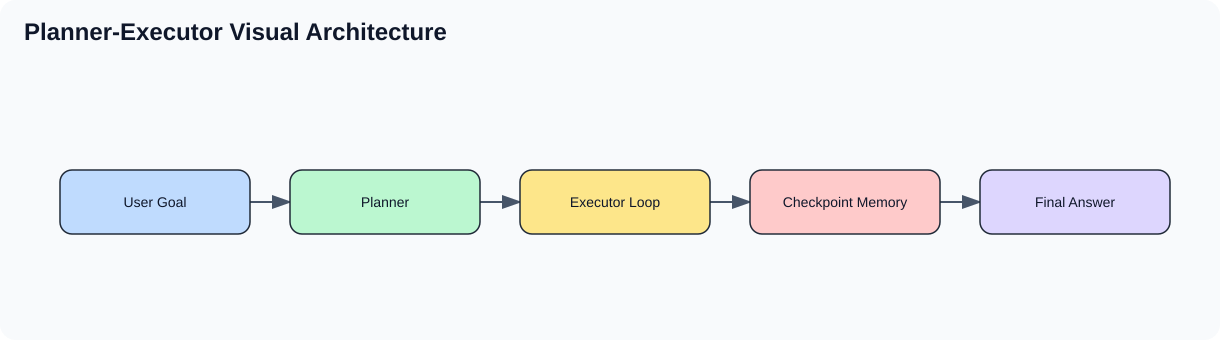

In [3]:
from visual_diagram_helper import render_svg_flow



nodes = [

    ("goal", "User Goal", 60, 170, "#bfdbfe"),

    ("planner", "Planner", 290, 170, "#bbf7d0"),

    ("executor", "Executor Loop", 520, 170, "#fde68a"),

    ("memory", "Checkpoint Memory", 750, 170, "#fecaca"),

    ("answer", "Final Answer", 980, 170, "#ddd6fe"),

]

edges = [

    ("goal", "planner"),

    ("planner", "executor"),

    ("executor", "memory"),

    ("memory", "answer"),

]



render_svg_flow("Planner-Executor Visual Architecture", nodes, edges, width=1220, height=340)

In [ ]:
# Reload shared helpers so any edits to agent_patterns_common.py take effect

# without needing to restart the kernel.

import importlib

import agent_patterns_common



importlib.reload(agent_patterns_common)

print("agent_patterns_common reloaded.")

### Planner-Executor State Graph

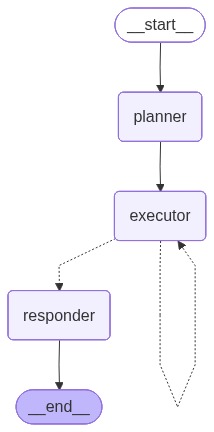

{"level": "INFO", "event_type": "planner_start", "goal": "Prepare a short briefing on AI agent design patterns"}
{"level": "INFO", "event_type": "llm_invoke_start", "attempt": 1, "prompt_preview": "You are a deterministic planner.\nReturn EXACTLY 3 lines.\nEach line must start wi"}
{"level": "INFO", "event_type": "llm_invoke_success", "attempt": 1}
{"level": "INFO", "event_type": "executor_step", "step_number": 1, "step_text": "STEP: Identify key components of an AI agent architecture."}
{"level": "INFO", "event_type": "executor_step", "step_number": 2, "step_text": "STEP: Determine the scope and requirements for the project."}
{"level": "INFO", "event_type": "executor_step", "step_number": 3, "step_text": "STEP: Outline the necessary design patterns for implementation."}
{"level": "INFO", "event_type": "planner_response_start", "completed": 3}
{"level": "INFO", "event_type": "llm_invoke_start", "attempt": 1, "prompt_preview": "You are a deterministic summarizer.\nReturn EXACTLY 4 bull

{'goal': 'Prepare a short briefing on AI agent design patterns',
 'plan': ['STEP: Identify key components of an AI agent architecture.',
  'STEP: Determine the scope and requirements for the project.',
  'STEP: Outline the necessary design patterns for implementation.'],
 'completed_steps': ['Executed: STEP: Identify key components of an AI agent architecture.',
  'Executed: STEP: Determine the scope and requirements for the project.',
  'Executed: STEP: Outline the necessary design patterns for implementation.'],
 'final_answer': '- Key components include perception, reasoning, action, and learning modules.\n- Scope and requirements determine the complexity and functionality of the agent.\n- Design patterns include Model-View-Controller (MVC) and Observer patterns.\n- Next steps involve implementing these patterns in code.',
 'history': ["Plan created: ['STEP: Identify key components of an AI agent architecture.', 'STEP: Determine the scope and requirements for the project.', 'STEP: O

In [ ]:
from langgraph.graph import END, START, StateGraph



from agent_pattern_states import PlannerState

from agent_patterns_common import (

    append_history,

    build_checkpointer,

    get_local_llm,

    invoke_with_retry,

    log_event,

    parse_lines,

    render_state_graph,

)





llm = get_local_llm()





def planner_node(state: PlannerState) -> PlannerState:

    log_event("info", "planner_start", goal=state["goal"])

    prompt = (

        "You are a deterministic planner.\n"

        "Return EXACTLY 3 lines.\n"

        "Each line must start with 'STEP:'.\n"

        "Each line must be <= 12 words.\n"

        f"Goal: {state['goal']}"

    )

    raw_plan = invoke_with_retry(llm, prompt)

    parsed_steps = parse_lines(raw_plan) or [

        "Understand the request",

        "Collect the key facts",

        "Draft the answer",

    ]

    return {

        "plan": parsed_steps[:3],

        "completed_steps": [],

        "history": append_history(state.get("history"), f"Plan created: {parsed_steps[:3]}"),

    }





def executor_node(state: PlannerState) -> PlannerState:

    step_index = len(state["completed_steps"])

    next_step = state["plan"][step_index]

    log_event("info", "executor_step", step_number=step_index + 1, step_text=next_step)

    updated_steps = state["completed_steps"] + [f"Executed: {next_step}"]

    return {

        "completed_steps": updated_steps,

        "history": append_history(state["history"], f"Completed step: {next_step}"),

    }





def route_after_execution(state: PlannerState) -> str:

    if len(state["completed_steps"]) < len(state["plan"]):

        return "executor"

    return "responder"





def responder_node(state: PlannerState) -> PlannerState:

    log_event("info", "planner_response_start", completed=len(state["completed_steps"]))

    prompt = (

        "You are a deterministic summarizer.\n"

        "Return EXACTLY 4 bullet points.\n"

        "Each bullet must start with '- '.\n"

        "Each bullet must be <= 16 words.\n"

        f"Goal: {state['goal']}\n"

        f"Completed steps: {state['completed_steps']}\n"

        f"History: {state['history']}"

    )

    return {

        "final_answer": invoke_with_retry(llm, prompt),

        "history": append_history(state["history"], "Final answer generated"),

    }





builder = StateGraph(PlannerState)

builder.add_node("planner", planner_node)

builder.add_node("executor", executor_node)

builder.add_node("responder", responder_node)

builder.add_edge(START, "planner")

builder.add_edge("planner", "executor")

builder.add_conditional_edges("executor", route_after_execution, {"executor": "executor", "responder": "responder"})

builder.add_edge("responder", END)



graph = builder.compile(checkpointer=build_checkpointer())

render_state_graph(graph, "Planner-Executor State Graph")



result = graph.invoke(

    {

        "goal": "Prepare a short briefing on AI agent design patterns",

        "plan": [],

        "completed_steps": [],

        "final_answer": "",

        "history": [],

    },

    config={"configurable": {"thread_id": "planner-executor-demo"}},

)



result

## Design insight



Planner-executor is useful when you need observability. The plan becomes inspectable state rather than hidden chain-of-thought.